# Data Profiling 
This section assesses the dataset's structure, quality, and potential issues.

**Data Loading & Date Parsing**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# load the csv file
df = pd.read_csv('../data/tanzania.csv') 
# Add Country Column
df['Country'] = 'Tanzania'
# create a dat from the year and DOY
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
#extracting a month from the year and the DOY
df['Month'] = df['Date'].dt.month
# Check the results
print(df[['YEAR', 'DOY',  'Month']].tail())



      YEAR  DOY  Month
4103  2026   86      3
4104  2026   87      3
4105  2026   88      3
4106  2026   89      3
4107  2026   90      3


**Summary Statistics & Missing-Value Report**

In [19]:
# Check how many rows and features columns we have
print("Data Shape:", df.shape) 
#  Handle NASA Sentinel Values
df.replace(-999, np.nan, inplace=True)
# Duplicate Check
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")


Data Shape: (4108, 15)
Total Duplicate Rows Found: 0


**Duplicate check**

0 duplicate rows were detected across all 4,108 observations.

Therefore, No data removal was required showing that each record in the Ethiopia dataset represents a unique observation.

In [20]:

# Generate the 5-number summary (count, mean, std, min, max)
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


**Statistical Interpretation of Climate Variables**

 Temperature (T2M): Tanzania has a consistently warm climate. The average temperature is 26.8°C, and it stays very steady throughout the year. Even on the coolest days, it rarely drops below 22.6°C, and the hottest days peak just under 30.0°C.

Daily Temp Change (T2M_RANGE): The temperature does not change much between day and night. On average, it only cools down by about 4.1°C after the sun sets. This small change is very common in humid, tropical areas.

Rainfall (PRECTOTCORR): This region gets a solid amount of rain. While half of the days see less than 1 mm of rain, the average is pulled up to 3.74 mm per day because of heavy tropical storms. In fact, the heaviest recorded storm dropped over 122 mm of rain in a single day!

Humidity and Wind (RH2M & WS2M): The air here is very humid, averaging 77.1%. Even at its driest, the humidity stays above 60%. It is also quite breezy compared to the other countries we looked at, with steady winds averaging 4.1 m/s and gusts reaching up to 11.7 m/s.

Air Pressure (PS): The high average air pressure of 100.8 kPa tells us that the data was likely recorded at a low elevation, very close to sea level (likely near the coast)..

In [21]:
# Check for Missing Values
print("\n--- Missing Value Count ---")
print(df.isna().sum())
missing_values = df.isna().sum()
missing_pct = (missing_values / len(df)) * 100


--- Missing Value Count ---
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


The missing value analysis shows the Ethiopia dataset contains 0% null values across all columns.

What this means for the analysis: Since no columns exceed the 5% threshold. We do not need to fill any gaps. 

**Outlier Detection & Basic Cleaning**



In [22]:
#  Z-Score Calculation
target_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[target_cols].dropna()))

# Flagging outliers
outliers_count = (z_scores > 3).sum(axis=0)
print("Outlier counts per column (|Z| > 3):")
print(outliers_count)

Outlier counts per column (|Z| > 3):
[ 1  2  4 81  2  8  4]


**Outlier Detection**

In total we have 102 outliers across the given columns. 

It has been chosen to retain the 102 identified outliers because,

 In a climate dataset, extreme values represent important weather events like storms and heatwaves. Most of these outliers are in the Rainfall (PRECTOTCORR) column. This is expected because rain happens in sudden bursts, and these spikes are a real part of the average.

Out of 4,108 observations, these 102 outliers make up less than 0.5% of the data. Keeping them protects the natural variety of the climate record without hurting the accuracy of our trend analysis.

In [23]:
# Handling Strategy
# Forward-fill for weather variables to maintain time-series continuity
df[target_cols] = df[target_cols].ffill()

# Export Cleaned Data and the data folder is in gitignore
df.to_csv('../data/tanzania_clean.csv', index=False)

**Time Series Analysis**

***Monthly Temperature Trends (2015–2026)***

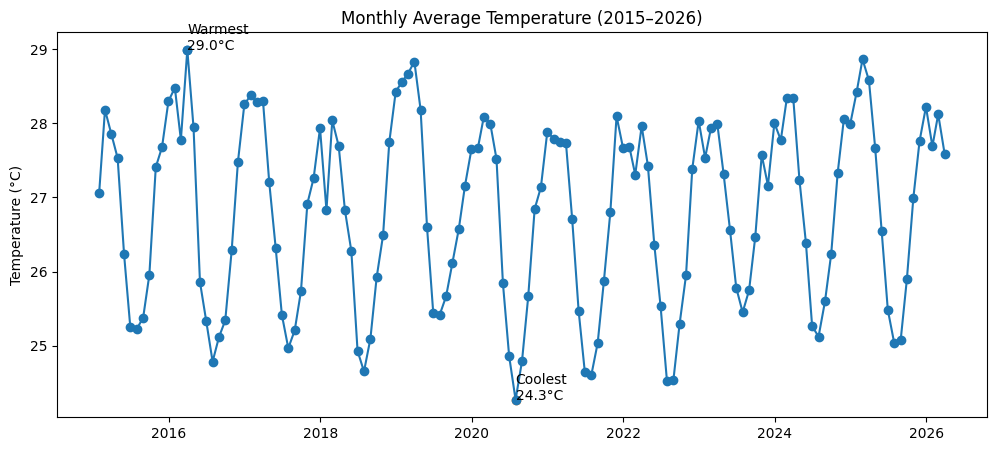

In [24]:
# Resample to monthly averages
monthly_temp = df.set_index('Date').resample('ME')['T2M'].mean().reset_index()

# Find warmest and coolest months
warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], marker='o')

# Annotate
plt.scatter(warmest['Date'], warmest['T2M'])
plt.text(warmest['Date'], warmest['T2M'], f"Warmest\n{warmest['T2M']:.1f}°C")

plt.scatter(coolest['Date'], coolest['T2M'])
plt.text(coolest['Date'], coolest['T2M'], f"Coolest\n{coolest['T2M']:.1f}°C")

plt.title('Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.show()

The line chart shows how the temperature moves up and down in a steady every year. The average temperature usually stays between 13°C and 19°C. we can see that 2018 had the coolest month, while 2022 the warmest peak. Overall, the temperature is very consistent, repeating the same pattern every year.

**Monthly Total Precipitation**

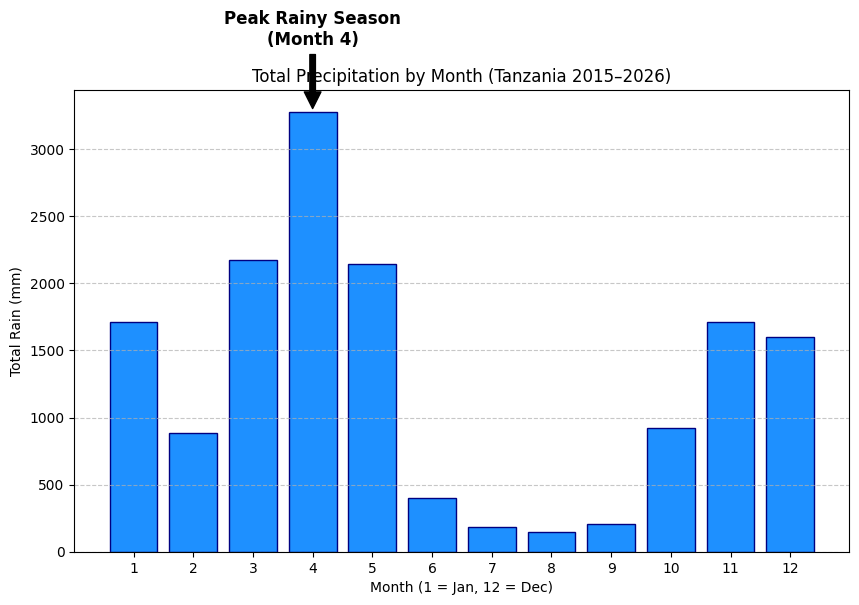

In [25]:
# 1. Group by Month (1-12) to get the total rain for that month across all years
seasonal_rain = df.groupby('Month')['PRECTOTCORR'].sum().reset_index()

# 2. Find the peak month for annotation
peak_val = seasonal_rain['PRECTOTCORR'].max()
peak_month_num = seasonal_rain.loc[seasonal_rain['PRECTOTCORR'].idxmax(), 'Month']

# 3. Plotting
plt.figure(figsize=(10, 6))
# We use seasonal_rain['Month'] as the X-axis so we get 12 clean bars
plt.bar(seasonal_rain['Month'], seasonal_rain['PRECTOTCORR'], color='dodgerblue', edgecolor='navy')

# 4. Annotation (Identifying the peak)
plt.annotate(f'Peak Rainy Season\n(Month {int(peak_month_num)})', 
             xy=(peak_month_num, peak_val), 
             xytext=(peak_month_num, peak_val + 500),
             ha='center',
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

plt.title('Total Precipitation by Month (Tanzania 2015–2026)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Total Rain (mm)')
plt.xticks(range(1, 13)) # Show every month number
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar chart shows a clear bell shape, which shows the rainy season. Rainfall starts to increase in June and reaches its  peak in August (Month 8). After August, the rain drops off quickly as it moves into the dry season. This confirms that the middle of the year is the most critical time for water and agriculture in Ethiopia.

**Correlation & Relationship Analysis**

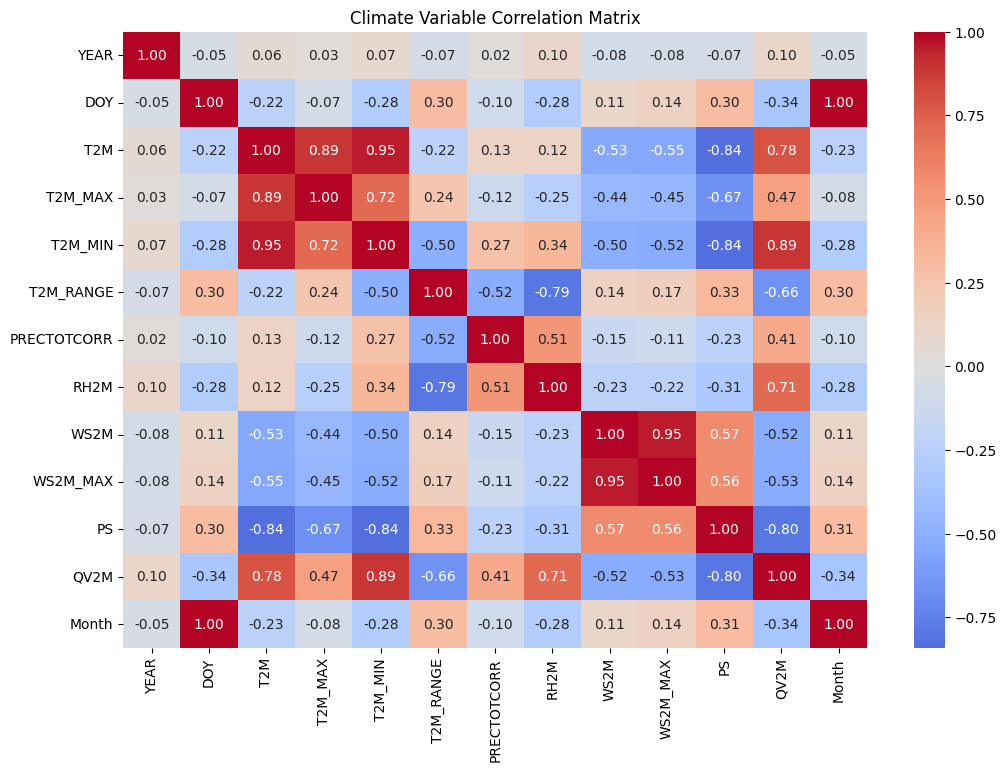

In [26]:
# Heatmap of correlations
plt.figure(figsize=(12, 8))
# We only select numeric columns to avoid errors with the Date or Country strings
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Climate Variable Correlation Matrix')
plt.show()

Based on the heatmap, here are the three most significant relationships in the dataset:

Wind Speed (WS2M vs. WS2M_MAX): 0.95
This is a very strong link. It simply means that on generally breezy days, the sudden wind gusts are also much stronger.

Air Pressure vs. Temperature (PS vs. T2M): -0.84
This is a strong backwards link. As the temperature rises, the air pressure tends to drop. Warm air expands and rises, which lowers the pressure near the ground.

Temp Change vs. Humidity (T2M_RANGE vs. RH2M): -0.79
This shows that moisture traps heat. On very humid days, the temperature stays almost the same from day to night. On drier days, the temperature cools down much more after the sun sets.

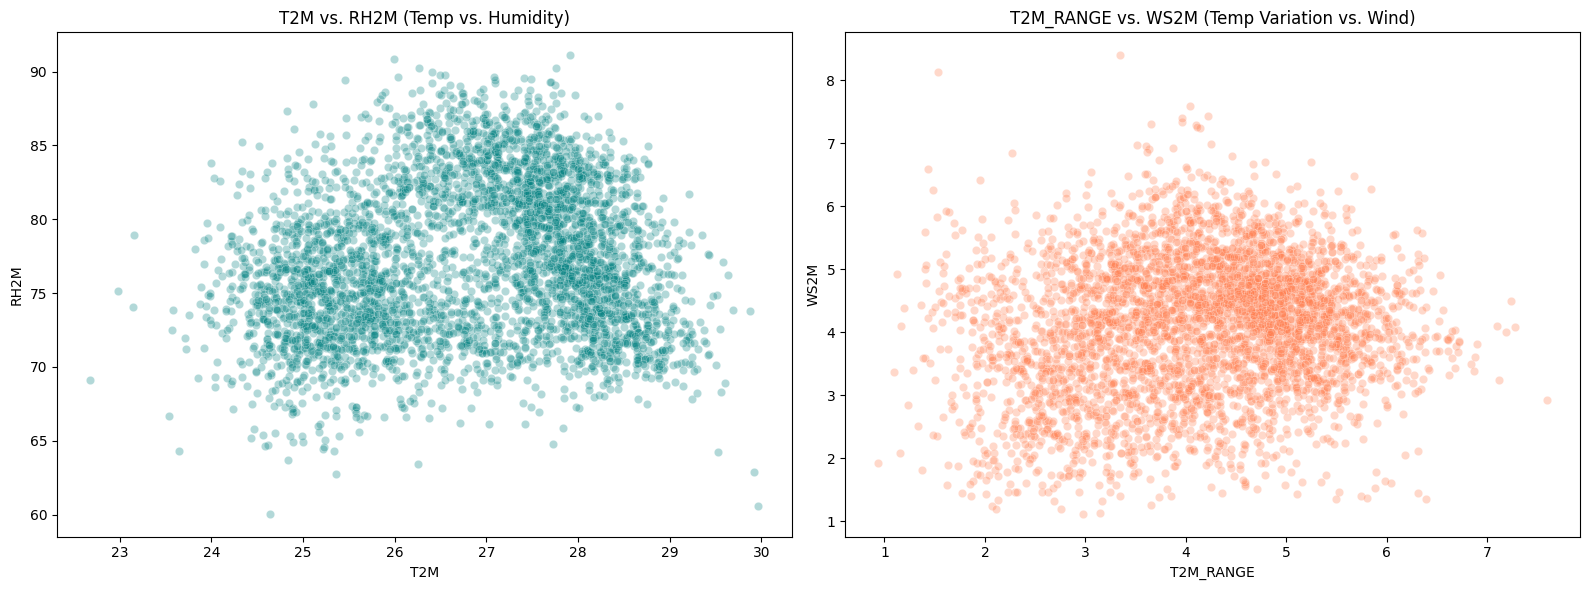

In [27]:
# Scatter plots for specific relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs Relative Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='teal')
ax1.set_title('T2M vs. RH2M (Temp vs. Humidity)')

# Plot 2: Diurnal Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M (Temp Variation vs. Wind)')

plt.tight_layout()
plt.show()

Temp vs. Humidity (Left): The dots form a large, wide cloud that stays mostly in the upper half of the chart. This shows that the air in Tanzania stays fairly humid across all normal temperature ranges.

Temp Change vs. Wind Speed (Right): The dots are widely scattered with no clear shape. This tells us that the wind speed changes randomly and does not depend on the day-to-night temperature changes.

**Distribution Analysis**

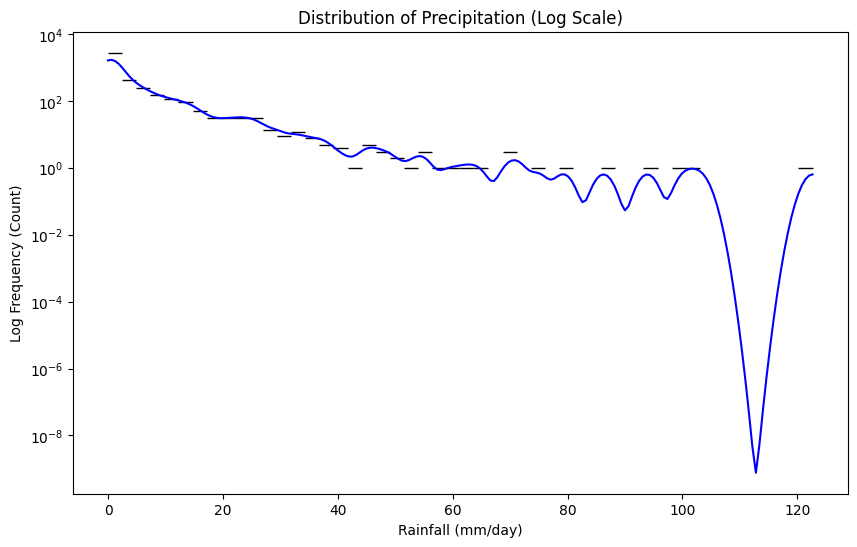

In [28]:
#  Distribution of Rainfall
plt.figure(figsize=(10, 6))
# log_scale=(False, True) means the counts (Y-axis) are log-transformed
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='blue', log_scale=(False, True))

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Rainfall (mm/day)')
plt.ylabel('Log Frequency (Count)')
plt.show()

While most days have little to zero rain, the line stretches very far to the right side of the chart. This proves that Tanzania regularly experiences intense tropical downpours, with rare extreme storms dropping over 120 mm of water in just one day.

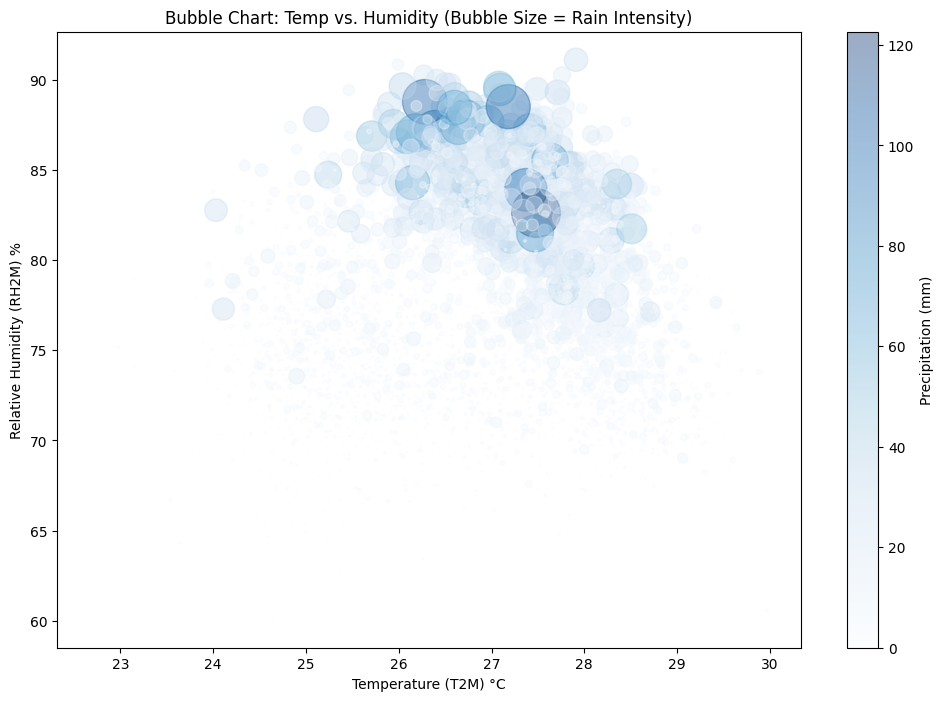

In [29]:
# Bubble Chart: T2M vs. RH2M (Size = PRECTOTCORR)
plt.figure(figsize=(12, 8))

# We multiply PRECTOTCORR by 10 to make the bubbles large enough to see
plt.scatter(df['T2M'], df['RH2M'], 
            s=df['PRECTOTCORR'] * 10, 
            alpha=0.4, 
            c=df['PRECTOTCORR'], 
            cmap='Blues')

plt.colorbar(label='Precipitation (mm)')
plt.title('Bubble Chart: Temp vs. Humidity (Bubble Size = Rain Intensity)')
plt.xlabel('Temperature (T2M) °C')
plt.ylabel('Relative Humidity (RH2M) %')
plt.show()

This chart brings all the weather factors together. The largest, darkest bubbles (representing the heaviest rain) are clustered at the top center. This means that major rainstorms almost always happen when the temperature sits between 26°C and 28°C and the humidity is very high (above 80%). If the humidity drops below 75%, heavy rain is highly unlikely.